# Latent Diffusion on MNIST

1. To tackle *conditional* generation, we will employ *classifier-free guidance* (CFG).
2. To parameterize our learned vector field for high-dimensional image-valued data, a simple MLP will not suffice. Instead, we adopt the *diffusion transformer* architecture (see part 2).

In [1]:
import os
from abc import ABC, abstractmethod
from typing import Optional, List, Type, Tuple
import math
import uuid
import random

from matplotlib import pyplot as plt
import torch
import torch.nn as nn
from torch.func import vmap, jacrev
from tqdm import tqdm
from torchvision import datasets, transforms
from torchvision.utils import make_grid
from einops import rearrange
from einops.layers.torch import Rearrange
from datasets import load_dataset

# Quiet install
%pip install lpips -q
import lpips

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 5.7 MB/s eta 0:00:00


### Part 0: Basic Components

In [2]:
class Sampleable(ABC):
    """
    Distribution which can be sampled from
    """
    @abstractmethod
    def sample(self, num_samples: int) -> torch.Tensor:
        """
        Args:
            - num_samples: the desired number of samples
        Returns:
            - samples: b d
        """
        pass

A dataset like MNIST contains both images (in this case handwritten digits), as well as class labels (a value from 0-9 indicating). We therefore generalize `Sampleable` to `LabeledSampleable` to accommodate these labels as well. Whereas the old, `Sampleable.sample` method returned only `samples: torch.Tensor`, `LabeledSampleable.sample` will return both `samples: torch.Tensor` *and* `labels: Optional[torch.Tensor]`. In this way, we are formally realizing every such `Sampleable` instance as sampling from a *joint distribution* over data and labels.

In [3]:
class LabeledSampleable(ABC):
    """
    Distribution which can be sampled from
    """
    @abstractmethod
    def sample(self, num_samples: int) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        """
        Args:
            - num_samples: the desired number of samples
        Returns:
            - samples: b d
            - labels: b
        """
        pass

For certain distributions, such as a Gaussian, it doesn't really make sense to think about labels. For this reason, we implement our Gaussian class as a simple Sampleable.

In [4]:
class IsotropicGaussian(nn.Module, Sampleable):
    """
    Sampleable wrapper around torch.randn
    """
    def __init__(self, shape: List[int], std: float = 1.0):
        """
        shape: shape of sampled data
        """
        super().__init__()
        self.shape = shape
        self.std = std
        self.dummy = nn.Buffer(torch.zeros(1)) # Will automatically be moved when self.to(...) is called...

    def sample(self, num_samples) -> torch.Tensor:
        return self.std * torch.randn(num_samples, *self.shape).to(self.dummy.device)

Our latent diffusion model is an instance of a conditional probability path. In general, diffusion works by finding the marginal path of a learned vector field from transforming a random (or arbitrary) distribution to the target distribution, which is described by the image dataset.

In [5]:
class ConditionalProbabilityPath(nn.Module, ABC):
    """
    Abstract base class for conditional probability paths
    """
    def __init__(self, p_simple: Sampleable, p_data: LabeledSampleable):
        super().__init__()
        self.p_simple = p_simple
        self.p_data = p_data

    def sample_marginal_path(self, t: torch.Tensor) -> torch.Tensor:
        """
        Samples from the marginal distribution p_t(x) = p_t(x|z) p(z)
        Args:
            - t: b
        Returns:
            - x: samples from p_t(x), b ... (i.e.,. `b d`, `b c h w`, etc.)
        """
        num_samples = t.shape[0]
        # Sample conditioning variable z ~ p(z)
        z, _ = self.sample_conditioning_variable(num_samples) # (b ...)
        # Sample conditional probability path x ~ p_t(x|z)
        x = self.sample_conditional_path(z, t) # (b ...)
        return x

    @abstractmethod
    def sample_conditioning_variable(self, num_samples: int) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Samples the conditioning variable z and label y
        Args:
            - num_samples: the number of samples
        Returns:
            - z: b ...
            - y: b
        """
        pass

    @abstractmethod
    def sample_conditional_path(self, z: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Samples from the conditional distribution p_t(x|z)
        Args:
            - z: conditioning variable b ...
            - t: time b
        Returns:
            - x: samples from p_t(x|z), b ...
        """
        pass

    @abstractmethod
    def conditional_vector_field(self, x: torch.Tensor, z: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates the conditional vector field u_t(x|z)
        Args:
            - x: b ...
            - z: b ...
            - t: b
        Returns:
            - conditional_vector_field: conditional vector field b c h w
        """
        pass

    @abstractmethod
    def conditional_score(self, x: torch.Tensor, z: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates the conditional score of p_t(x|z)
        Args:
            - x: b ...
            - z: b ...
            - t: b
        Returns:
            - score: b ...
        """
        pass

`LinearAlpha` and `LinearBeta`, for VAE training.

Also, to save on compute, we use a `GaussianConditionalProbabilityPath` instead of a sophisticated learned scheduler. This does sacrifice performance, but it also makes it feasible to train (relatively) quickly.

In [6]:
class Alpha(ABC):
    def __init__(self):
        # Check alpha_t(0) = 0
        assert torch.allclose(
            self(torch.zeros(1,)), torch.zeros(1,)
        )
        # Check alpha_1 = 1
        assert torch.allclose(
            self(torch.ones(1,)), torch.ones(1,)
        )

    @abstractmethod
    def __call__(self, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates alpha_t. Should satisfy: self(0.0) = 0.0, self(1.0) = 1.0.
        Args:
            - t: b
        Returns:
            - alpha_t: b
        """
        pass

    def dt(self, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates d/dt alpha_t.
        Args:
            - t: b
        Returns:
            - d/dt a_t: b
        """
        t = t.unsqueeze(1)
        dt = vmap(jacrev(self))(t)
        return dt.view(-1)

class Beta(ABC):
    def __init__(self):
        # Check beta_0 = 1
        assert torch.allclose(
            self(torch.zeros(1)), torch.ones(1)
        )
        # Check beta_1 = 0
        assert torch.allclose(
            self(torch.ones(1)), torch.zeros(1)
        )

    @abstractmethod
    def __call__(self, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates alpha_t. Should satisfy: self(0.0) = 1.0, self(1.0) = 0.0.
        Args:
            - t: b
        Returns:
            - beta_t: b
        """
        pass

    def dt(self, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates d/dt beta_t.
        Args:
            - t: b
        Returns:
            - d/dt beta_t: b
        """
        t = t.unsqueeze(1)
        dt = vmap(jacrev(self))(t)
        return dt.view(-1)

class LinearAlpha(Alpha):
    """
    Implements alpha_t = t
    """

    def __call__(self, t: torch.Tensor) -> torch.Tensor:
        """
        Args:
            - t: b
        Returns:
            - alpha_t: b
        """
        return t

    def dt(self, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates d/dt alpha_t.
        Args:
            - t: b
        Returns:
            - d/dt alpha_t b
        """
        return torch.ones_like(t)

class LinearBeta(Beta):
    """
    Implements beta_t = 1-t
    """
    def __call__(self, t: torch.Tensor) -> torch.Tensor:
        """
        Args:
            - t: b
        Returns:
            - beta_t: b
        """
        return 1-t

    def dt(self, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates d/dt alpha_t.
        Args:
            - t: b
        Returns:
            - d/dt alpha_t: b
        """
        return - torch.ones_like(t)

class GaussianConditionalProbabilityPath(ConditionalProbabilityPath):
    def __init__(self, p_data: Sampleable, p_simple_shape: List[int], alpha: Alpha, beta: Beta):
        p_simple = IsotropicGaussian(shape = p_simple_shape, std = 1.0)
        super().__init__(p_simple, p_data)
        self.alpha = alpha
        self.beta = beta
        self.rearrange_scalar = Rearrange(f'b -> b{" 1" * len(p_simple_shape)}')

    def sample_conditioning_variable(self, num_samples: int) -> torch.Tensor:
        """
        Samples the conditioning variable z and label y
        Args:
            - num_samples: the number of samples
        Returns:
            - z: b ...
            - y: b
        """
        return self.p_data.sample(num_samples)

    def sample_conditional_path(self, z: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Samples from the conditional distribution p_t(x|z)
        Args:
            - z: b ...
            - t: b
        Returns:
            - x: b ...
        """
        alpha_t = self.rearrange_scalar(self.alpha(t)) # (b 1 1 1)
        beta_t = self.rearrange_scalar(self.beta(t)) # (b 1 1 1)
        return alpha_t * z + beta_t * torch.randn_like(z)

    def conditional_vector_field(self, x: torch.Tensor, z: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates the conditional vector field u_t(x|z)
        Args:
            - x: b c h w
            - z: b c h w
            - t: b
        Returns:
            - conditional_vector_field: conditional vector field (num_samples, c, h, w)
        """
        alpha_t = self.rearrange_scalar(self.alpha(t)) # b
        beta_t = self.rearrange_scalar(self.beta(t)) # b
        dt_alpha_t = self.rearrange_scalar(self.alpha.dt(t)) # b
        dt_beta_t = self.rearrange_scalar(self.beta.dt(t)) # b

        return (dt_alpha_t - dt_beta_t / beta_t * alpha_t) * z + dt_beta_t / beta_t * x

    def conditional_score(self, x: torch.Tensor, z: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates the conditional score of p_t(x|z)
        Args:
            - x: b ...
            - z: b ...
            - t: b
        Returns:
            - conditional_score: b ...
        """
        alpha_t = self.rearrange_scalar(self.alpha(t))
        beta_t = self.rearrange_scalar(self.beta(t))
        return (z * alpha_t - x) / beta_t ** 2

Based on Stable Diffusion 3 and Flux 2, we use rectified flow as our sampling technique during inference of the LDM (latent diffusion model).

In [7]:
class ODE(ABC):
    @abstractmethod
    def drift_coefficient(self, xt: torch.Tensor, t: torch.Tensor, **kwargs) -> torch.Tensor:
        """
        Returns the drift coefficient of the ODE.
        Args:
            - xt: b ...
            - t: b
        Returns:
            - drift_coefficient: b ...
        """
        pass

In [8]:
class Simulator(ABC):
    @abstractmethod
    def step(self, xt: torch.Tensor, t: torch.Tensor, dt: torch.Tensor, **kwargs):
        """
        Takes one simulation step
        Args:
            - xt: b ...
            - t: b
            - dt: b
        Returns:
            - nxt: b ...
        """
        pass

    @torch.no_grad()
    def simulate(self, x: torch.Tensor, ts: torch.Tensor, use_tqdm: bool = True, **kwargs):
        """
        Simulates using the discretization gives by ts
        Args:
            - x_init: b ...
            - ts: b
        Returns:
            - x_final: b ...
        """
        nts = ts.shape[1]
        pbar = tqdm(range(nts - 1)) if use_tqdm else range(nts - 1)
        for t_idx in pbar:
            t = ts[:, t_idx]
            h = ts[:, t_idx + 1] - ts[:, t_idx]
            x = self.step(x, t, h, **kwargs)
        return x

    @torch.no_grad()
    def simulate_with_trajectory(self, x: torch.Tensor, ts: torch.Tensor, use_tqdm: bool = True, **kwargs):
        """
        Simulates using the discretization gives by ts
        Args:
            - x: b ...
            - ts: b nt
        Returns:
            - x_traj: b nt ...
        """
        x_traj = [x.clone()]
        nts = ts.shape[1]
        pbar = tqdm(range(nts - 1)) if use_tqdm else range(nts - 1)
        for t_idx in pbar:
            t = ts[:,t_idx]
            h = ts[:, t_idx + 1] - ts[:, t_idx]
            x = self.step(x, t, h, **kwargs)
            x_traj.append(x.clone())
        return torch.stack(x_traj, dim=1)

class EulerSimulator(Simulator):
    def __init__(self, ode: ODE):
        self.ode = ode

    def step(self, xt: torch.Tensor, t: torch.Tensor, h: torch.Tensor, **kwargs):
        h = h.view([-1] + [1] * (len(xt.shape) - 1))
        return xt + self.ode.drift_coefficient(xt, t, **kwargs) * h

def record_every(num_timesteps: int, record_every: int) -> torch.Tensor:
    """
    Compute the indices to record in the trajectory given a record_every parameter
    """
    if record_every == 1:
        return torch.arange(num_timesteps)
    return torch.cat(
        [
            torch.arange(0, num_timesteps - 1, record_every),
            torch.tensor([num_timesteps - 1]),
        ]
    )

Finally, basic `Trainer` definition.

In [9]:
MiB = 1024 ** 2

def model_size_b(model: nn.Module) -> int:
    """
    Returns model size in bytes. Based on https://discuss.pytorch.org/t/finding-model-size/130275/2
    Args:
    - model: self-explanatory
    Returns:
    - size: model size in bytes
    """
    size = 0
    for param in model.parameters():
        size += param.nelement() * param.element_size()
    for buf in model.buffers():
        size += buf.nelement() * buf.element_size()
    return size


class Trainer(ABC):
    def __init__(
        self,
        **kwargs
      ):
        super().__init__()
        self.model = None
        self.opt = None
        self.output_dir = None

    @abstractmethod
    def get_train_loss(self, **kwargs) -> torch.Tensor:
        pass

    def checkpoint(self, step: int):
      pass

    def get_optimizer(self, lr: float):
        return torch.optim.AdamW(self.model.parameters(), lr=lr, weight_decay=1e-4)

    def random_name(self) -> str:
        adjectives = ["autumn", "hidden", "bitter", "misty", "silent", "empty", "dry", "dark", "summer", "icy", "delicate", "quiet", "white", "cool", "spring", "winter", "patient"]
        foods = ["apple", "banana", "pear", "plum", "orange", "persimmon", "tangerine", "durian", "jackfruit", "jicama", "cantaloupe", "watermelon", "peach"]
        return f"{random.choice(adjectives)}-{random.choice(foods)}-{str(uuid.uuid4())[:8]}"

    def train(
        self,
        model: nn.Module,
        num_steps: int,
        lr: float = 1e-3,
        warmup_steps: int = 500,
        ckpt_every: Optional[int] = 500,
        run_name: Optional[str] = None,
        **kwargs
    ) -> Tuple[List[float], List[int]]:
        """
        Linear warmup from 0 -> lr over `warmup_steps`, then constant lr.
        """
        # Initialize run name and output directory
        run_name = run_name or self.random_name()
        self.output_dir = os.path.join("runs", run_name)
        os.makedirs(self.output_dir, exist_ok=False)
        print("Initialized output directory at: " + self.output_dir)

        # Grab size
        self.model = model
        size_b = model_size_b(self.model)
        print(f"Training model with size: {size_b / MiB:.3f} MiB")

        # Initialize optimizer and LR
        self.opt = self.get_optimizer(lr)
        self.model.train()

        for pg in self.opt.param_groups:
            pg["lr"] = 0.0

        # Main training loop
        losses: List[float] = []
        steps: List[int] = []

        pbar = tqdm(range(num_steps))
        for step in pbar:
            # Update LR
            if warmup_steps > 0 and step < warmup_steps:
                cur_lr = lr * float(step + 1) / float(warmup_steps)
            else:
                cur_lr = lr
            for pg in self.opt.param_groups:
                pg["lr"] = cur_lr

            # Forward + backward
            self.opt.zero_grad(set_to_none=True)
            loss = self.get_train_loss(**kwargs)
            loss.backward()

            # Take gradient step
            self.opt.step()

            losses.append(float(loss.detach().item()))
            steps.append(step)

            pbar.set_description(f"Step {step}, lr={cur_lr:.2e}, loss={loss.item():.4f}")

            # Callback if specified
            if ckpt_every is not None and step % ckpt_every == 0 and step > 0:
              self.model.eval()
              self.checkpoint(step)
              self.model.train()

        self.model.eval()
        return losses, list(range(num_steps))

# Part 1: CelebA Sampling

In [ ]:
import numpy as np

class CelebASampler(nn.Module, LabeledSampleable):
    """
    Sampleable wrapper for the CelebA dataset returning images and multi-attribute labels.

    The default PyTorch CelebA downloads the images from Google Drive, which can fail for a long time.
    See: https://discuss.pytorch.org/t/same-google-drive-dataset-download-error-for-several-weeks-now/171231

    To mitigate this, I switched to this celeba dataset someone uploaded into Hugging Face. All they did was
    download the PyTorch celeba from Google Drive and upload to Hugging Face, so it is perfectly compatible.
    """
    def __init__(self, root: str = './data', img_size: int = 64, split: str = 'train'):
        super().__init__()
        self.img_size = img_size
        self.dataset = load_dataset("eurecom-ds/celeba", split=split)

        # Transforms optimized for batched tensor input instead of single PIL images
        self.transform = transforms.Compose([
            transforms.Resize((img_size, img_size), antialias=True),
            transforms.CenterCrop((img_size, img_size)),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
        ])
        self.n_attrs = 40
        self.dummy = nn.Buffer(torch.zeros(1))

    def sample(self, num_samples: int) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Args:
            - num_samples: the desired number of samples
        Returns:
            - samples: shape (batch_size, c, h, w)
            - attributes: shape (batch_size, n_attributes)
        """
        if num_samples > len(self.dataset):
            raise ValueError(f"num_samples exceeds dataset size: {len(self.dataset)}")

        # Fetch batch of random indices all at once to leverage HF datasets caching and batched I/O
        indices = torch.randperm(len(self.dataset))[:num_samples].tolist()
        items = self.dataset[indices]

        # Fast batched conversion: PIL -> numpy -> tensor (B, H, W, C) -> (B, C, H, W)
        images_np = np.stack([np.array(img) for img in items["image"]])
        images_t = torch.from_numpy(images_np).permute(0, 3, 1, 2).float().div(255.0)

        # Apply batched transforms
        samples = self.transform(images_t).to(self.dummy.device)

        # Extract attributes (items["attributes"] is a list of lists of attributes)
        # Leaving them as {-1, 1} allows us to safely use 0.0 as the null label for CFG
        attributes = torch.tensor(items["attributes"]).to(self.dummy.device).float()
        return samples, attributes


In [11]:
class ConditionalVectorField(nn.Module, ABC):
    """
    Conditional vector field u_t^theta(x|y)
    """

    @abstractmethod
    def forward(self, x: torch.Tensor, t: torch.Tensor, y: torch.Tensor):
        """
        Args:
        - x: b ...
        - t: b
        - y: b
        Returns:
        - u_t^theta(x|y): b ...
        """
        pass

class CFGVectorFieldODE(ODE):
    def __init__(self, net: ConditionalVectorField, null_label: int, guidance_scale: float = 1.0):
        self.net = net
        self.guidance_scale = guidance_scale
        self.null_label = null_label

    def drift_coefficient(self, x: torch.Tensor, t: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        """
        Args:
        - x: b ...
        - t: b
        - y: b
        """
        guided_vector_field = self.net(x, t, y)
        unguided_y = torch.ones_like(y) * self.null_label
        unguided_vector_field = self.net(x, t, unguided_y)
        return (1 - self.guidance_scale) * unguided_vector_field + self.guidance_scale * guided_vector_field


In [12]:
class MLP(nn.Module):
  def __init__(self, dims: List[int], activation: Type[torch.nn.Module] = torch.nn.SiLU, final_init: bool = False):
    super().__init__()
    mlp = []
    for idx in range(len(dims) - 1):
        mlp.append(torch.nn.Linear(dims[idx], dims[idx + 1]))
        if idx < len(dims) - 2:
            mlp.append(activation())
    self.net = torch.nn.Sequential(*mlp)

    if final_init:
      nn.init.zeros_(self.net[-1].weight)
      nn.init.zeros_(self.net[-1].bias)

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    """
    Args:
    - x: b n d
    Returns:
    - x: b n d
    """
    return self.net(x)

# Part 2: Building a Diffusion Transformer

### Classifier-Free Guidance

Used to increase prompt adherence (in our case, label adherence, since we're not including a text incoder to do full text-to-image).

Maps a scalar time value $t \in [0,1]$ to
$$
    t^{\text{emb}} = \begin{bmatrix}
    \cos(2\pi w_1 t) & \cdots & \cos(2\pi w_d t) & \sin(2\pi w_1 t) & \cdots & \sin(2\pi w_d t)
    \end{bmatrix}^T,
$$
where the weights $w_i \sim \mathcal{N}(0, 1)$ are drawn from a unit normal.

In [13]:
class FourierEncoder(nn.Module):
    """
    Based on https://github.com/lucidrains/denoising-diffusion-pytorch/blob/main/denoising_diffusion_pytorch/karras_unet.py#L183
    """
    def __init__(self, dim: int):
        super().__init__()
        assert dim % 2 == 0
        self.half_dim = dim // 2
        self.weights = nn.Parameter(torch.randn(1, self.half_dim))

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        """
        Args:
        - t: b
        Returns:
        - embeddings: b d
        """
        # Step 1: compute frequencies f_i = 2 * pi * w_i * t
        t = t.view(-1, 1) # b 1
        freqs = t * self.weights * 2 * math.pi # b hd

        # Step 2: compute sin(f_i) and cos(f_i)
        sin_embed = torch.sin(freqs) # b hd
        cos_embed = torch.cos(freqs) # b hd

        # Step 3: Concatenate and return
        return torch.cat([sin_embed, cos_embed], dim=-1) * math.sqrt(2) # b d

### Patchifier

The patchifier takes in an image-valued tensor of shape `b c 32 32`, and *patchifies* it to shape `b (h / p * w / p) d`, where `d` denotes the diffusion transformer hidden dimension (`dim` in the implementation below), `p` denotes the patch size, and `h` and `w` denote the image height and width, respectively. It does this in two steps:
1. Applies a convolutional layer mapping the an input of shape `b c 32 32` to `b d h/p h/w`.
2. Rearranges from `b d h/p h/w` to `b (h/p h/w) d` (i.e., `n = h/p * h/w` tokens with dimension `d`).

In [14]:
class Patchifier(nn.Module):
  def __init__(self, img_size: int, patch_size: int, c_in: int, dim: int):
    super().__init__()
    assert img_size % patch_size == 0, "Image size must be divisible by patch size"

    self.net = nn.Sequential(
        # Initial convolution
        nn.Conv2d(c_in, dim, kernel_size=patch_size, stride=patch_size),

        # Patchify
        Rearrange("b d h w -> b (h w) d"),
    )

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    """
    Args:
    - x: (bs, 1, img_size, img_size)
    Returns:
    - x: (bs, 1, img_size, img_size)
    """
    return self.net(x)

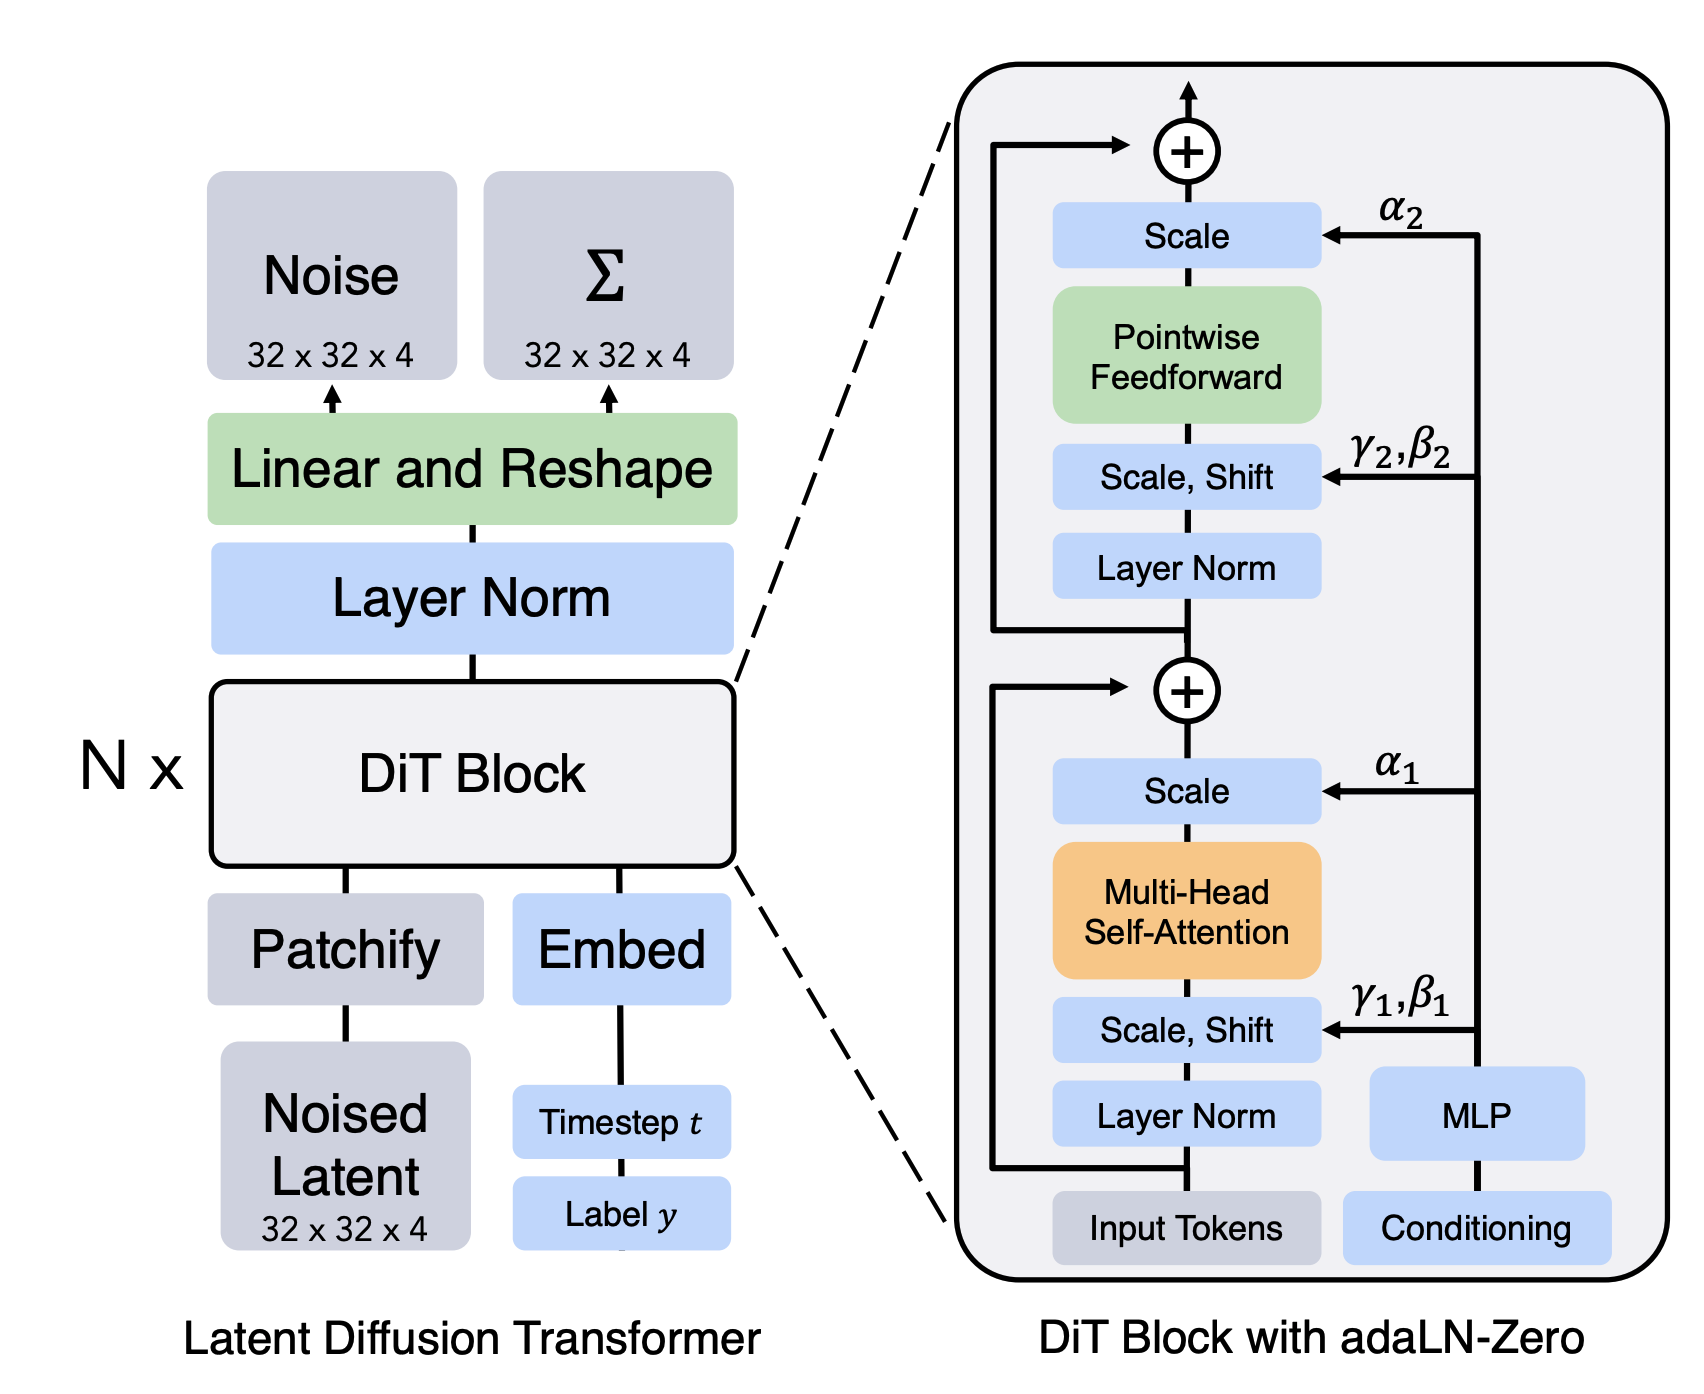

### Diffusion Transformer
Our data is now in the shape `b n d`, where `n` denotes the number of image tokens per image. We'll now pass it through a transformer

**Pieces:**
1. `DiffusionTransformerLayer` is based on the diagram above. AdaLN-Zero refers to zero-initializing the conditioning MLP weights (the last layer will suffice), which often helps to stablize training.
2. `DiffusionTransformer`learns fixed per-position encodings using e.g., `nn.Parameter(torch.randn(n_tokens, dim))`. A forward pass simply involves adding the positional encodings to your input and passing through the diffusion transformer layers.

In [ ]:
def apply_rope(q, k, freqs):
    """
    Added RoPE support to the MHA implementation to improve model performance on the more complex CelebA dataset.

    When initially training with MNIST, the model worked fine without RoPE, but when training on CelebA,
    the model struggled to learn meaningful attention patterns and had poor sample quality.

    After adding RoPE, the model was able to learn much more effectively and produce significantly better samples.
    """
    # Using torch.polar for fast radians conversion and complex multiplication, which is much faster than manually computing sin/cos and doing the rotation ourselves.
    q_complex = torch.view_as_complex(q.float().reshape(*q.shape[:-1], -1, 2))
    k_complex = torch.view_as_complex(k.float().reshape(*k.shape[:-1], -1, 2))
    # freqs expected in radians
    theta = torch.polar(torch.ones_like(freqs), freqs)
    q_out = torch.view_as_real(q_complex * theta).flatten(-2)
    k_out = torch.view_as_real(k_complex * theta).flatten(-2)
    return q_out.type_as(q), k_out.type_as(k)

class MHA(nn.Module):
  """
  Multi-headed self-attention
  """
  def __init__(self, dim: int, heads: int, use_rope: bool = False):
    super().__init__()
    self.heads = heads
    self.head_dim = dim // heads
    self.use_rope = use_rope
    self.qkv = nn.Linear(dim, dim * 3)
    self.proj = nn.Linear(dim, dim)

  def forward(self, x: torch.Tensor, rope_freqs: Optional[torch.Tensor] = None) -> torch.Tensor:
    """
    Args:
    - x: b n d
    Returns:
    - x: b n d

    nn.MultiheadAttention expects (batch, seq_len, dim) if batch first is true
    """
    b, n, _ = x.shape
    qkv = self.qkv(x).reshape(b, n, 3, self.heads, self.head_dim).permute(2, 0, 3, 1, 4)
    q, k, v = qkv[0], qkv[1], qkv[2]
    if self.use_rope and rope_freqs is not None:
        q, k = apply_rope(q, k, rope_freqs)
    attn = torch.nn.functional.scaled_dot_product_attention(q, k, v)
    out = attn.transpose(1, 2).reshape(b, n, -1)
    return self.proj(out)

def modulate(x: torch.Tensor, scale: torch.Tensor, bias: torch.Tensor) -> torch.Tensor:
    """
    Args:
    - x: b n d
    - scale: b n d
    - bias: b n d
    Returns:
    - x: b n d
    """
    return x * (1 + scale) + bias

class DiffusionTransformerLayer(nn.Module):
  def __init__(self, dim: int, heads: int, use_rope: bool = False):
    """
    Args:
    - n_tokens: sequence length (for sake of positional embeddings)
    - dim: dimension of hidden layers
    - heads: number of attention heads
    - use_rope: whether to apply rope
    """
    super().__init__()
    # Init normalization

    # AdaLN provides affine parameters
    self.norm1 = nn.RMSNorm(dim, elementwise_affine=False)
    self.norm2 = nn.RMSNorm(dim, elementwise_affine=False)
    self.ada_ln = nn.Sequential(nn.RMSNorm(dim, elementwise_affine=False), nn.Linear(dim, dim * 6))
    # Initialize conditioning to zero - stabilizes residual connection
    nn.init.zeros_(self.ada_ln[1].weight)
    nn.init.zeros_(self.ada_ln[1].bias)
    # Attention
    self.attn = MHA(dim, heads, use_rope=use_rope)
    # Feed-forward
    self.ff = MLP([dim, 4 * dim, dim])

  def forward(self, x: torch.Tensor, c: torch.Tensor, rope_freqs: Optional[torch.Tensor] = None) -> torch.Tensor:
    """
    Args:
    - x: b n d
    - c: b d
    - rope_freqs:
    Returns:
    - x: b n d
    """
   # Compute conditioning gating, scaling, and bias

   # Faster than looping through each part of the adaptive layer norm
    c = rearrange(self.ada_ln(c), 'b d -> b 1 d') # b 1 d
    attn_scale, attn_bias, attn_gate, ff_scale, ff_bias, ff_gate = c.chunk(6, dim=-1)
    # Attention + FF
    x = x + attn_gate * self.attn(modulate(self.norm1(x), attn_scale, attn_bias), rope_freqs=rope_freqs)
    x = x + ff_gate * self.ff(modulate(self.norm2(x), ff_scale, ff_bias))
    return x

class DiffusionTransformer(nn.Module):
  def __init__(self, depth: int, n_tokens: int, dim: int, heads: int, use_rope: bool = True):
    """
    Args:
    - n_tokens: sequence length (for sake of positional embeddings)
    - dim: dimension of hidden layers
    - heads: number of attention heads
    - depth: number of layers
    - use_rope: Whether to use rope
    """
    super().__init__()
    self.layers = nn.ModuleList([DiffusionTransformerLayer(dim, heads, use_rope) for _ in range(depth)])
    self.use_rope = use_rope
    if use_rope:
        grid_size = int(math.sqrt(n_tokens))
        self.rope_freqs = self.create_2d_rope(grid_size, dim // heads)
    else:
        self.pos_encodings = nn.Parameter(torch.randn(n_tokens, dim))

  def create_2d_rope(self, grid_size, head_dim):
    """
    Creates 2D RoPE frequencies for a grid of size (grid_size x grid_size) and head dimension head_dim.

    Added RoPE support to the Diffusion Transformer implementation to improve model performance on the more complex CelebA dataset.
    """
    pos = torch.stack(torch.meshgrid(torch.arange(grid_size), torch.arange(grid_size), indexing='ij'), -1).reshape(-1, 2)
    inv_freq = 1.0 / (10000 ** (torch.arange(0, head_dim, 4).float() / head_dim))
    freqs_x = pos[:, 0:1] * inv_freq
    freqs_y = pos[:, 1:2] * inv_freq
    return torch.cat([freqs_x, freqs_y], dim=-1)

  def forward(self, x: torch.Tensor, c: torch.Tensor) -> torch.Tensor:
    """
    Add positional encoding to input and pass through diffusion layers

    Args:
    - x: b n d
    - c: b d
    Returns:
    - x: b n d
    """
    if not self.use_rope:
        x = x + self.pos_encodings.unsqueeze(0)
    freqs = self.rope_freqs.to(x.device) if self.use_rope else None
    for layer in self.layers:
      x = layer(x, c, rope_freqs=freqs)
    return x

### Depatchifier
After the diffusion transformer, we need to convert from `b n d` back to `b 1 h w`.

In [16]:
class Depatchifier(nn.Module):
  def __init__(self, img_size: int, patch_size: int, dim: int, final_dim: int, c_out: int):
      super().__init__()
      self.patch_size = patch_size
      assert img_size % patch_size == 0, "Image size must be divisible by patch size"
      h = w = img_size // patch_size


      self.net = nn.Sequential(
          # Norm + MLP
          nn.RMSNorm(dim, elementwise_affine=False),
          MLP([dim, 4*dim, final_dim * patch_size ** 2]),

          # Depatchify
          Rearrange("b (h w) (f ph pw) -> b f (h ph) (w pw)", h=h, w=w, f=final_dim, ph=patch_size, pw=patch_size),

          # Final convolution
          nn.Conv2d(final_dim, c_out, kernel_size=3, padding=1)
      )

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    """
    Args:
    - x: b n d
    Returns:
    - x: b 1 32 32
    """
    return self.net(x)

### DiffusionTransformerFlowModel

DiT-based guided flow model $u_t^\theta(x|y)$ based on the DiT overview diagram.

In [17]:
class DiffusionTransformerFlowModel(ConditionalVectorField):
  def __init__(self, img_size: int = 32, patch_size: int = 8, num_layers: int = 12, c: int = 1, dim: int = 256, heads: int = 4, final_dim: int = 10, n_attrs: int = 40):
      super().__init__()
      # 0. Construct time_embedder and y_embedder
      self.time_embedder = FourierEncoder(dim)
      self.n_attrs = n_attrs
      self.y_project = nn.Sequential(nn.Linear(self.n_attrs, dim), nn.SiLU(), nn.Linear(dim, dim))

      # 1. Construct patchifier
      self.patchifier = Patchifier(img_size=img_size, patch_size=patch_size, c_in=c, dim=dim)
      # 2. Construct DiT
      n_tokens = (img_size // patch_size) ** 2
      self.dit = DiffusionTransformer(depth=num_layers, n_tokens=n_tokens, dim=dim, heads=heads, use_rope=True)
      # 3. Construct de-patchifier
      self.depatchifier = Depatchifier(img_size=img_size, patch_size=patch_size, dim=dim, final_dim=final_dim, c_out=c)

  def forward(self, x: torch.Tensor, t: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    """
    Args:
    - x: b 1 32 32
    - t: b 1 1 1
    - c: b 1 1 1
    Returns:
    - u_t^theta(x|y): b 1 32 32
    """

    # 1. Embed time and y
    t_embed = self.time_embedder(t).unsqueeze(1)

    if y.dim() == 1 or (y.dim() == 2 and y.dtype in (torch.int32, torch.int64)):
        y_onehot = torch.zeros(y.shape[0], self.n_attrs, device=y.device)
        y_onehot.scatter_(1, y.long().unsqueeze(1), 1.0)
        y = y_onehot
    y_embed = self.y_project(y.float()).unsqueeze(1)

    # 2. Patchify
    x = self.patchifier(x)
    # 3. Pass through DiT
    x = self.dit(x, (t_embed + y_embed).squeeze(1))

    # 4. Depatchify
    x = self.depatchifier(x)
    return x

# Part 3: Training a Variational Autoencoder

In this section, we'll train a variational autoencoder (VAE) for MNIST. In the next section, we'll then train a diffusion transformer inside of the learned latent space.

**Pieces:**
1. an *encoder* $q_\phi(z|x)$, mapping the input `x` with shape `b 1 32 32`, to outputs `z_mean` with shape `b c h w` and learned scalar `z_logvar`. For training stability reasons, and in following the precedent of [2], we choose to indirectly parameterize the log-variance $\log \sigma_\phi(x)$.
2. a *decoder* $p_\theta(x|z)$ which similarly maps the latent `z` to outputs `x_mean` with shape `b 1 32 32` and learned scalar `x_logvar`.

### Residual Block

In [18]:
class ResidualBlock(nn.Module):
  """ Two applications of LN + convolution + non-linearity + residual connection """
  def __init__(self, channels: int, act: nn.Module = nn.SiLU):
    super().__init__()

    # Init norm, convolutions, and activations
    self.norm = nn.GroupNorm(num_groups=1, num_channels=channels)
    self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
    self.conv2 = nn.Conv2d(channels, channels, kernel_size=1, padding=0)
    self.activation = act()

    # Initialize the second convolution to zero to stabilize training early on
    nn.init.zeros_(self.conv2.weight)
    nn.init.zeros_(self.conv2.bias)

  def forward(self, x: torch.Tensor):

    # Res init
    x_skip = x

    # Norm
    x = self.norm(x)

    # First convolution
    x = self.conv1(x)

    # Activation
    x = self.activation(x)

    # Second convolution
    x = self.conv2(x)

    # Return residual connection
    return x_skip + x

### Attention Block

In [19]:
class AttentionBlock(nn.Module):
  def __init__(self, channels: int):
    super().__init__()

    # Reshape from image shape to list of tokens shape
    self.reshape1 = Rearrange('b c h w -> b (h w) c')

    # Norm + attention
    self.norm1 = nn.LayerNorm(channels)
    self.mha = MHA(channels, 1)

    # Norm + feed forward
    self.norm2 = nn.LayerNorm(channels)
    self.feedforward = MLP([channels, 2 * channels, channels], final_init=True)

  def forward(self, x: torch.Tensor):
    b, c, h, w = x.shape
    x = self.reshape1(x)

    x_skip = x

    # Attention + residual connection
    x = self.norm1(x)
    x = self.mha(x)
    x = x + x_skip

     # Feedforward + residual connection
    x_skip = x
    x = self.norm2(x)
    x = self.feedforward(x)
    x = x + x_skip

    return rearrange(x, 'b (h w) c -> b c h w', h=h, w=w)

### Encoder

In [20]:
class EncoderBlock(nn.Module):
  def __init__(self, in_channels: int, downsample_channels: Optional[int] = None, use_attention: bool = False):
    super().__init__()

    layers = [
      ResidualBlock(in_channels),
      ResidualBlock(in_channels),
    ]
    if use_attention:
        layers.append(AttentionBlock(in_channels))

    self.net = nn.Sequential(*layers)

    if downsample_channels is not None:
      self.downsample = nn.Conv2d(in_channels = in_channels, out_channels = downsample_channels, padding=1, stride=2, kernel_size=3)
    else:
      self.downsample = None

  def forward(self, x: torch.Tensor):

    x = self.net(x)
    if self.downsample is not None:
      x = self.downsample(x)
    return x


class Encoder(nn.Module):
  def __init__(self, in_channels: int, hidden_channels: list[int]):
    super().__init__()

    # Initial conv2d
    self.init_conv = nn.Conv2d(in_channels = in_channels, out_channels = hidden_channels[0], kernel_size=3, padding=1, stride=1)

    # Initialize channels
    ch_in = hidden_channels
    ch_out = hidden_channels[1:] + [None]
    blocks = []
    for idx, (in_c, out_c) in enumerate(zip(ch_in, ch_out)):
      # Only apply attention at the lowest resolution (the final encoder block)
      # Otherwise running out of memory
      use_attention = (idx == len(ch_in) - 1)
      blocks.append(EncoderBlock(in_c, out_c, use_attention=use_attention))
    self.blocks = nn.ModuleList(blocks)

    # Predict z_mean
    z_dim = hidden_channels[-1]
    self.z_mean = nn.Sequential(
      nn.GroupNorm(1, z_dim),
      nn.Conv2d(in_channels = z_dim, out_channels = z_dim, kernel_size=1, stride=1, padding=0),
    )

    # Scalar log-variance
    self.logvar = nn.Parameter(torch.zeros(()))

  def forward(self, x: torch.Tensor):
    # Initial convolution
    x = self.init_conv(x)

    # Pass through blocks
    for block in self.blocks:
      x = block(x)

    # Final normalization + convolution to get z_mean
    return self.z_mean(x), self.logvar


### Decoder

In [21]:
class DecoderBlock(nn.Module):
  def __init__(self, in_channels: int, upsample_channels: Optional[int] = None, use_attention: bool = False):
    super().__init__()
    layers = [
      ResidualBlock(in_channels),
      ResidualBlock(in_channels),
    ]
    if use_attention:
        layers.append(AttentionBlock(in_channels))

    self.net = nn.Sequential(*layers)

    if upsample_channels is not None:
      self.upsample = nn.Sequential(
        nn.Upsample(scale_factor=2, mode='nearest'),
        nn.Conv2d(in_channels=in_channels, out_channels=upsample_channels, kernel_size=3, padding=1, stride=1),
      )
    else:
      self.upsample = None

  def forward(self, x: torch.Tensor):
    x = self.net(x)
    if self.upsample is not None:
      x = self.upsample(x)
    return x

class Decoder(nn.Module):
  def __init__(self, out_channels: int, hidden_channels: list[int]):
    super().__init__()

    # Initialize channels
    ch_in = hidden_channels
    ch_out = hidden_channels[1:] + [None]
    blocks = []
    for idx, (in_c, out_c) in enumerate(zip(ch_in, ch_out)):
      # Only apply attention at the lowest resolution (the first decoder block)
      # Otherwise running out of memory
      use_attention = (idx == 0)
      blocks.append(DecoderBlock(in_c, out_c, use_attention=use_attention))
    self.blocks = nn.ModuleList(blocks)

    # Predict mean
    x_dim = hidden_channels[-1]
    self.x_mean = nn.Sequential(
      nn.GroupNorm(1, x_dim),
      nn.Conv2d(in_channels = x_dim, out_channels = out_channels, kernel_size=1, stride=1, padding=0),
    )

    # Scalar log-variance
    self.logvar = nn.Parameter(torch.zeros(()))

  def forward(self, x: torch.Tensor):
    # Pass through blocks
    for block in self.blocks:
      x = block(x)

    # Final normalization + convolution to get x_mean
    return self.x_mean(x), self.logvar

### Complete VAE

In [22]:
class VAE(nn.Module):
  def __init__(self, data_channels: int, hidden_channels: list[int], beta: float = 0.1, perceptual_weight: float = 0.1):
    super().__init__()
    self.beta = beta
    self.perceptual_weight = perceptual_weight

    # Encoder and Decoder
    self._encoder = Encoder(data_channels, hidden_channels)
    self._decoder = Decoder(data_channels, list(reversed(hidden_channels)))

    # LPIPS model for perceptual loss
    # Added to address VAE bluriness
    # Based on Stable Diffusion 3's use of LPIPS
    self.lpips = lpips.LPIPS(net='vgg').eval()
    for param in self.lpips.parameters():
        param.requires_grad = False

  def encode(self, x: torch.Tensor):
    return self._encoder(x)

  def decode(self, z: torch.Tensor):
    return self._decoder(z)

  def forward(self, x: torch.Tensor):
    z_mean, z_logvar = self.encode(x)
    z = z_mean + torch.exp(0.5 * z_logvar) * torch.randn_like(z_mean)
    x_mean, x_logvar = self.decode(z)
    return z_mean, z_logvar, x_mean, x_logvar

  def compute_loss(self, z_mean: torch.Tensor, z_logvar: torch.Tensor, x_mean: torch.Tensor, x_logvar: torch.Tensor, x_true: torch.Tensor):
    eps = 1e-6

    # KL loss
    kl_loss = self.beta * (z_mean.pow(2) + torch.exp(z_logvar) - z_logvar - 1).mean()

    # Reconstruction loss (Pixel-wise)
    mse_term = (x_true - x_mean).pow(2) / (torch.exp(x_logvar) + eps)
    pixel_loss = (mse_term + x_logvar).mean()

    # Perceptual Loss (LPIPS)
    # LPIPS expects tensors in [-1, 1], matching our CelebA preprocessing.
    p_loss = self.lpips(x_mean, x_true).mean()

    return kl_loss + pixel_loss + self.perceptual_weight * p_loss

Before we train, we create a new `Trainer` subclass with which to train the VAE, and a helper function to visualize interpolation in the learned latent space.

In [23]:
class CelebaVAETrainer(Trainer):
  def __init__(self, celeba_sampleable: LabeledSampleable, batch_size: int = 64, **kwargs):
    super().__init__(**kwargs)
    self.celeba = celeba_sampleable
    self.batch_size = batch_size

  def get_train_loss(self):
    x, y = self.celeba.sample(self.batch_size)
    z_mean, z_std, x_mean, x_std = self.model(x)
    return self.model.compute_loss(z_mean, z_std, x_mean, x_std, x)

  @torch.no_grad()
  def checkpoint(self, step: int):
    # Save model
    torch.save(self.model.state_dict(), os.path.join(self.output_dir, f'step_{step:06d}_model.pt'))
    torch.save(self.opt.state_dict(), os.path.join(self.output_dir, f'step_{step:06d}_opt.pt'))

    # Save output visualization, using x_mean as reconstruction
    b = 10
    x, _ = self.celeba.sample(b)
    _, _, x_mean, _ = self.model(x)
    x_all = torch.cat([x, x_mean], dim=0)
    grid = make_grid(x_all, nrow=b, normalize=True, value_range=(0,1))
    plt.imshow(grid.permute(1, 2, 0).cpu(), cmap="gray")
    plt.axis("off")
    plt.title("VAE Reconstruction")
    plt.savefig(os.path.join(self.output_dir, f'step_{step:06d}_output.png'))
    plt.close()

@torch.no_grad()
def visualize_latent_interpolation(x1: torch.Tensor, x2: torch.Tensor, vae: VAE, n_steps: int):
    z1_mean, z1_logvar = vae.encode(x1)
    z1 = z1_mean + torch.exp(0.5 * z1_logvar) * torch.randn_like(z1_mean)

    z2_mean, z2_logvar = vae.encode(x2)
    z2 = z2_mean + torch.exp(0.5 * z2_logvar) * torch.randn_like(z2_mean)

    lambdas = torch.linspace(0, 1, n_steps).to(z1.device)
    zs = (1 - lambdas.view(-1, 1, 1, 1)) * z1 + lambdas.view(-1, 1, 1, 1) * z2
    samples, _ = vae.decode(zs)

    # Inverse normalize and clamp for RGB display
    samples = torch.clamp(samples * 0.5 + 0.5, 0, 1)

    grid = make_grid(samples, nrow=n_steps, normalize=False)
    plt.figure(figsize=(n_steps * 2, 2))
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
    plt.axis("off")
    plt.title("Latent Interpolation (CelebA)")
    plt.show()
    return samples

Finally, let's train the VAE.

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Access to the secret `HF_TOKEN` has not been granted on this notebook.
You will not be requested again.
Please restart the session if you want to be prompted again.
  warnings.warn(


README.md:   0%|          | 0.00/4.04k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

data/train-00000-of-00018.parquet:   0%|          | 0.00/480M [00:00<?, ?B/s]

...

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 224MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth
Initialized output directory at: runs/empty-pear-e728cc24
Training model with size: 121.770 MiB


Step 9999, lr=1.00e-04, loss=-0.7931: 100%|██████████| 10000/10000 [17:48<00:00,  9.36it/s]


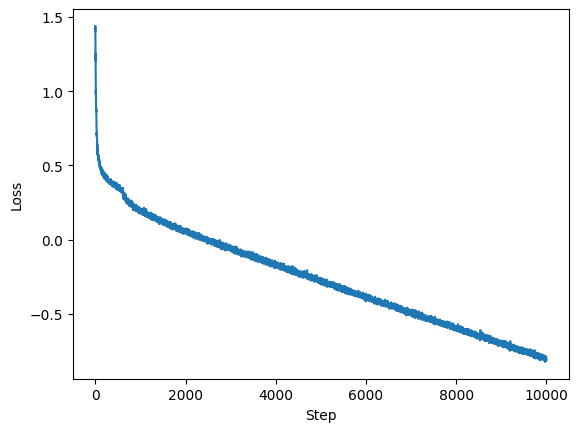

In [24]:
# Create dataset + VAE
device = torch.device('cuda')
celeba = CelebASampler(img_size=128).to(device)

vae = VAE(
   data_channels = 3,
   hidden_channels = [64, 128, 256, 512, 16],
   beta = 0.01, # Reduced KL penalty for sharper reconstructions
   perceptual_weight = 0.5 # LPIPS weight
).to(device)

# Create Trainer + train
trainer = CelebaVAETrainer(
    celeba_sampleable = celeba,
    batch_size = 16,
)
losses, steps = trainer.train(
   model = vae,
   num_steps = 10000,
   lr = 1e-4,
   warmup_steps = 500,
   ckpt_every = 1000,
)
plt.plot(steps, losses)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.show()

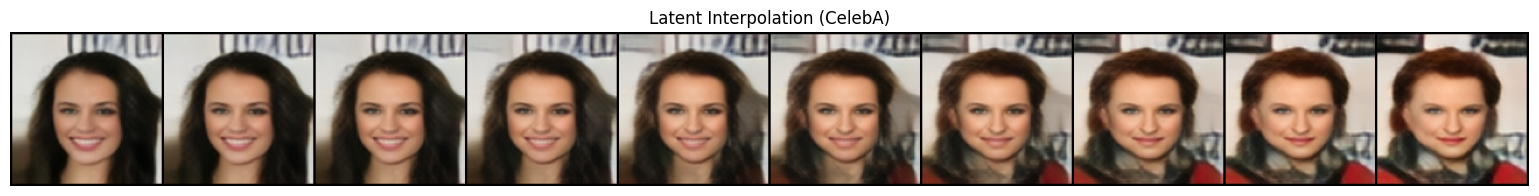

In [25]:
# Perform interpolation in the latent space
vae.eval()
samples, _ = celeba.sample(2)
interpolated_samples = visualize_latent_interpolation(
   x1 = samples[:1],
   x2 = samples[1:2],
   vae = vae,
   n_steps = 10,
)

# Part 4: Training a Latent Diffusion Model
In this section, we'll train a diffusion transformer inside of the latent space of a trained VAE.

In [26]:
class LatentCFGTrainer(Trainer):
    def __init__(self, celeba: LabeledSampleable, vae: VAE, path: GaussianConditionalProbabilityPath, eta: float, null_label: Optional[int], eps: float = 0.001, **kwargs):
        super().__init__(**kwargs)
        self.celeba = celeba
        self.vae = vae
        self.path = path
        self.eta = eta
        self.eps = eps
        self.null_label = null_label

    @torch.no_grad()
    def visualize_samples(self, save_path: Optional[str] = None, num_timesteps: int = 100, guidance_scales: List[float] = [1.0, 3.0, 5.0], use_tqdm: bool = False):
        self.model.eval()

        # Graph
        fig, axes = plt.subplots(1, len(guidance_scales), figsize=(10 * len(guidance_scales), 10))

        num_samples = 16

        for idx, w in enumerate(guidance_scales):
            # Setup ode and simulator
            ode = CFGVectorFieldODE(net=self.model, null_label=self.null_label if self.null_label is not None else 0.0, guidance_scale=w)
            simulator = EulerSimulator(ode)

            # Sample initial conditions
            z0 = self.path.p_simple.sample(num_samples)
            _, y = self.celeba.sample(num_samples)

            # Correct time shape: (batch, num_steps)
            ts_single = torch.linspace(0, 0.999, num_timesteps).to(z0.device)
            ts = ts_single.unsqueeze(0).expand(num_samples, -1)

            z1 = simulator.simulate(z0, ts, y=y, use_tqdm=use_tqdm)

            # Decode
            x1, _ = self.vae.decode(z1)

            # Inverse normalize from [-1, 1] to [0, 1] for display
            x1 = torch.clamp(x1 * 0.5 + 0.5, 0, 1)

            # Plot
            grid = make_grid(x1, nrow=4, normalize=False)

            axes[idx].imshow(grid.permute(1, 2, 0).cpu(), cmap="gray")
            axes[idx].axis("off")
            axes[idx].set_title(f"Guidance: $w={w:.1f}$", fontsize=25)

        # Save
        if save_path is not None:
           plt.savefig(save_path)
           plt.close(fig)
        else:
            plt.show()

    def checkpoint(self, step: int):
      # Save model
      torch.save(self.model.state_dict(), os.path.join(self.output_dir, f'step_{step:6d}_model.pt'))
      torch.save(self.opt.state_dict(), os.path.join(self.output_dir, f'step_{step:6d}_opt.pt'))

      # Save output visualization
      self.visualize_samples(save_path=os.path.join(self.output_dir, f'step_{step:6d}_output.png'))

    def get_train_loss(self, batch_size: int) -> torch.Tensor:
        # Step 1: Sample z, y from CelebA + encode
        with torch.no_grad():
            xx, y = self.celeba.sample(batch_size)
            z_mean, z_logvar = self.vae.encode(xx)
            zz = z_mean + torch.exp(0.5 * z_logvar) * torch.randn_like(z_mean)

        # Step 2: Set each label to null_label with probability eta
        yi = torch.rand(y.shape[0], device=y.device)
        y[yi < self.eta] = self.null_label if self.null_label is not None else 0.0

        # Step 3: Sample t and x
        t = torch.rand(batch_size).to(zz) * (1 - self.eps) # b
        zx = self.path.sample_conditional_path(zz,t) # b ...

        # Step 4: Regress and output loss
        ut_theta = self.model(zx,t,y) # b ...
        ut_ref = self.path.conditional_vector_field(zx,zz,t) # b ...
        return torch.square(ut_theta - ut_ref).mean()


Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/18 [00:00<?, ?it/s]

Initialized output directory at: runs/delicate-peach-d25aa1de
Training model with size: 221.609 MiB


Step 9999, lr=1.00e-04, loss=1.9830: 100%|██████████| 10000/10000 [42:12<00:00,  3.95it/s]


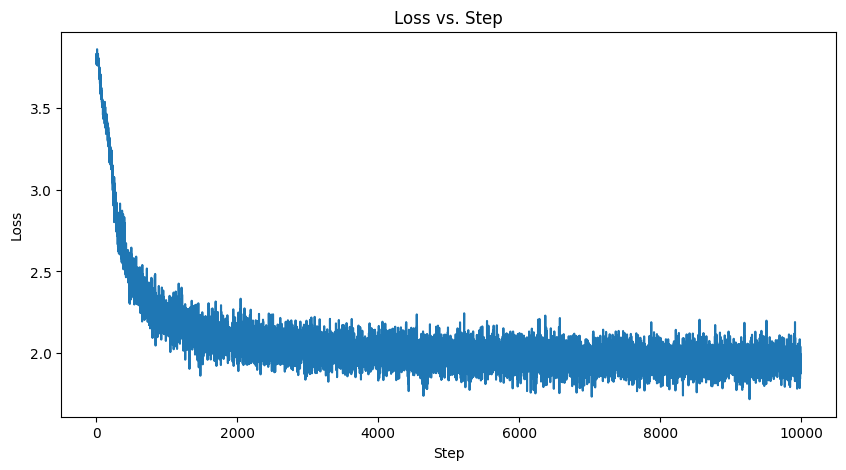

In [27]:
# Finally, let's train!

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
vae = vae.to(device)

# Latent dimensions: 16 channels, 8x8 spatial grid
latent_c = 16
latent_size = 8

path = GaussianConditionalProbabilityPath(
    p_data=None,
    p_simple_shape=[latent_c, latent_size, latent_size],
    alpha=LinearAlpha(),
    beta=LinearBeta()
).to(device)

# Initialize model
dit = DiffusionTransformerFlowModel(
    img_size=latent_size,
    patch_size=1, # Since latent is already small (8x8), we use patch size 1
    num_layers=12,
    c=latent_c,
    dim=512,
    heads=8,
    final_dim=latent_c,
    n_attrs=celeba.n_attrs
).to(device)

# Dataset
celeba = CelebASampler(root='./data', img_size=128, split='train').to(device)

# Initialize trainer
trainer = LatentCFGTrainer(celeba=celeba, vae=vae, path=path, eta=0.35, null_label=0.0)

# Training takes about 40 minutes on A100
losses, steps = trainer.train(model=dit, num_steps=10000, lr=1e-4, batch_size=64, ckpt_every=1000)

# Only plotting the loss curve here
plt.figure(figsize=(10, 5))
plt.plot(steps, losses)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Loss vs. Step")
plt.show()


### Inference using the Latent Diffusion Model

100%|██████████| 99/99 [00:02<00:00, 41.67it/s]


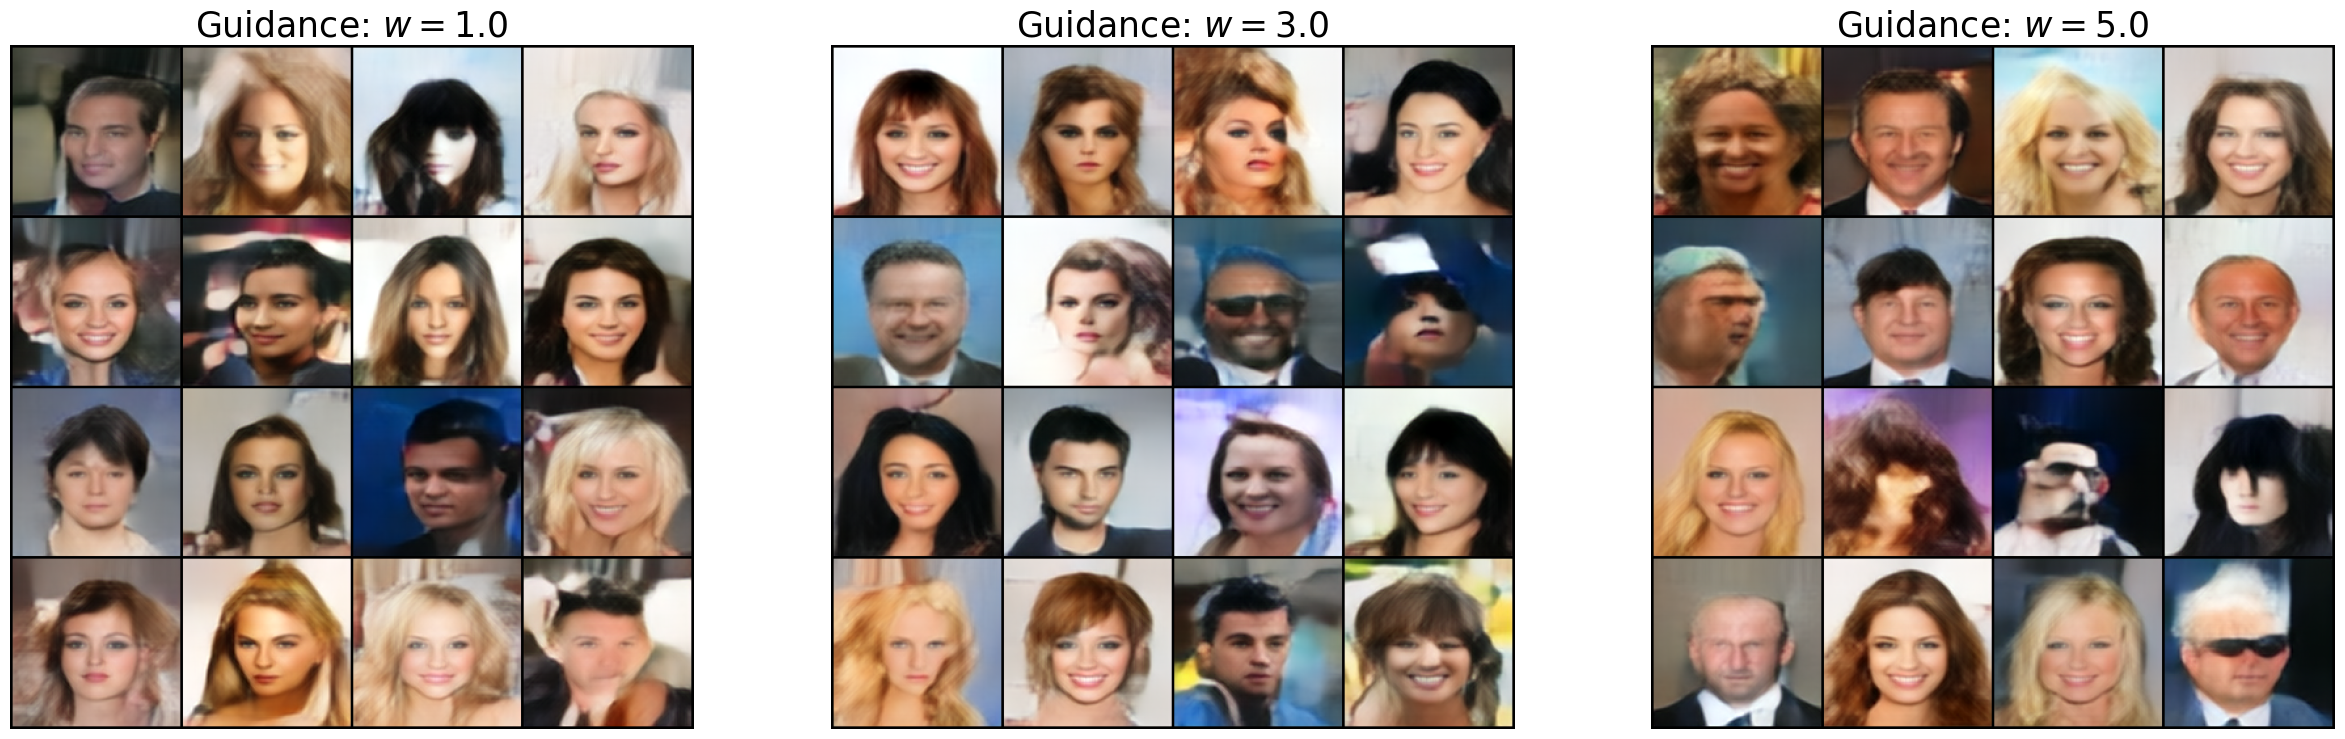

In [28]:
trainer.visualize_samples(save_path=None, use_tqdm=True)

### References:
1. [Scalable Diffusion Models with Transformers](https://arxiv.org/abs/2212.09748) -> DiT paper
2. [High-Resolution Image Synthesis with Latent Diffusion Models](https://arxiv.org/abs/2112.10752) -> Latent Diffusion Model paper
3. [Flow Straight and Fast: Learning to Generate and Transfer Data with Rectified Flow](https://arxiv.org/abs/2209.03003) -> Rectified Flow paper
4. [Scaling Rectified Flow Transformers for High-Resolution Image Synthesis](https://arxiv.org/abs/2403.03206) -> Stable Diffusion 3 paper